# P3: Oldindan o'qitilgan embeddinglar bilan ishlash

**Mavzu:** word embeddings, kosinus o'xshashlik, analogiya, PCA vizualizatsiya  
**Kun:** 4-kun amaliyoti — Day 3 vektor-fazo ma'ruzasiga bog'langan practice  
**Ma'lumot:** haqiqiy Uzbek static embedding fayli — tavsiya: fastText `cc.uz.300.vec.gz`  
**GPU:** kerak emas; Kaggle CPU yetarli.

Bugun `uz_mini.vec` fallback ishlatmaymiz. Vazifa: Kaggle dataset sifatida real Uzbek static embedding faylini attach qilish va undan so'z vektorlarini yuklash. Katta fayl sekin yuklanmasligi uchun top-N (`EMBEDDING_LIMIT`) vektorlar bilan ishlaymiz.

Tavsiya etilgan manba: fastText pretrained vectors sahifasidan Uzbek `cc.uz.300.vec.gz` fayli: https://fasttext.cc/docs/en/crawl-vectors.html

**Muhim farq:** Word2Vec/GloVe/fastText kabi static embeddinglarda `.vec`, `.vec.gz` yoki `.kv` faylning o'zi allaqachon so'z→vektor jadvalidir. Biz matnni modeldan o'tkazmaymiz; tokenlarni olib, har bir token uchun vektorni lookup qilamiz. BERT kabi contextual embeddinglarda esa butun matn modeldan o'tkaziladi.

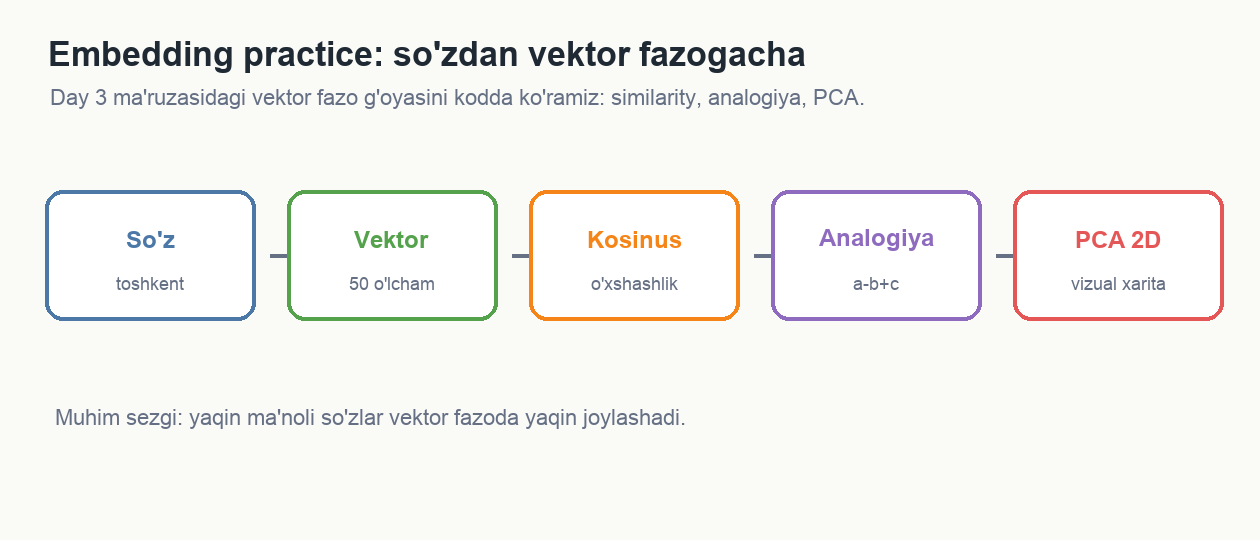

**Bugungi maqsadlar:**
1. Word2Vec `.vec` formatini yuklash.
2. So'z vektorini olish va OOV holatini ko'rish.
3. Kosinus similarity va `most_similar` yozish.
4. `toshkent - uzbekiston + rossiya ≈ moskva` analogiyasini tekshirish.
5. PCA bilan embeddinglarni 2D ko'rish.
6. `PretrainedEmbedder` klassining yengil capstone previewini ko'rish.


In [2]:
# ============================================================
# 1. Muhit tekshiruvi va haqiqiy static embedding faylni topish
# ============================================================
import gzip
import random
import sys
from pathlib import Path

import numpy as np

random.seed(42)
np.random.seed(42)

SAVE_CAPSTONE_MODULE = False  # True -> m03_pretrained_embedder.py faylga yoziladi (ixtiyoriy)
EMBEDDING_LIMIT = 50_000      # Kaggle RAM/vaqt uchun top-N so'z vektorlarini yuklaymiz

# Tavsiya etilgan Kaggle dataset fayli:
#   cc.uz.300.vec.gz  (fastText Uzbek, text word2vec format)
# Alternativlar:
#   cc.uz.300.vec, uzbek.vec, uzbek.vec.gz, yoki oldindan saqlangan .kv
PREFERRED_EMBEDDING_NAMES = [
    "cc.uz.300.vec.gz",
    "cc.uz.300.vec",
    "uzbek.vec.gz",
    "uzbek.vec",
    "uzbek.kv",
]


def is_supported_embedding(path: Path) -> bool:
    name = path.name.lower()
    return name.endswith((".vec", ".vec.gz", ".txt", ".txt.gz", ".kv"))


def find_embedding_file() -> Path | None:
    search_roots = []
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        search_roots.append(kaggle_root)
    search_roots.extend([Path("."), Path("..")])

    found = []
    for root in search_roots:
        if root.exists():
            found.extend([p for p in root.rglob("*") if p.is_file() and is_supported_embedding(p)])

    for preferred in PREFERRED_EMBEDDING_NAMES:
        for path in found:
            if path.name == preferred:
                return path
    return found[0] if found else None


VECTOR_PATH = find_embedding_file()
assert VECTOR_PATH is not None, (
    "Haqiqiy Uzbek static embedding fayli topilmadi. Kaggle'da fastText Uzbek "
    "`cc.uz.300.vec.gz` faylini dataset sifatida attach qiling yoki .vec/.vec.gz/.kv "
    "embedding fayl yuklang. Bu notebook endi uz_mini.vec fallback ishlatmaydi."
)

MODULES_DIR = Path("capstone/modules")

print(f"Python      : {sys.version.split()[0]}")
print(f"numpy       : {np.__version__}")
try:
    import sklearn
    print(f"scikit-learn: {sklearn.__version__}")
except ImportError:
    print("scikit-learn: yo'q — PCA/cosine_similarity uchun Kaggle muhitini tekshiring")
try:
    import matplotlib
    print(f"matplotlib  : {matplotlib.__version__}")
except ImportError:
    print("matplotlib  : yo'q — PCA jadval sifatida ko'rsatiladi")
try:
    import gensim
    print(f"gensim      : {gensim.__version__} (real .vec/.kv yuklash uchun ishlatiladi)")
except ImportError:
    print("gensim      : yo'q — .vec/.vec.gz numpy loader bilan o'qiladi")
print(f"Embedding file: {VECTOR_PATH}")
print(f"Embedding limit: {EMBEDDING_LIMIT:,} so'z")
print("Muhit tayyor.")


Python      : 3.12.13
numpy       : 2.0.2
scikit-learn: 1.6.1
matplotlib  : 3.10.0
gensim      : 4.4.0 (real .vec/.kv yuklash uchun ishlatiladi)
Embedding file: /kaggle/input/datasets/khilolakhushmanova/nlp-p4/uz_mini.vec
Embedding limit: 50,000 so'z
Muhit tayyor.


## 2. Darsda ko'rsatiladigan barcha natijalarni ko'rib chiqamiz  

Quyida **tugallangan embedding demosi** ishga tushadi: real static vektor faylini yuklaymiz va
demo so'zga eng o'xshash so'zlarni topamiz. Avval natijani ko'rib olamiz.

In [3]:
# Pirovard natija (5-bo'limda quriladigan m03 ning soddalashtirilgan versiyasi)
# Real static embedding: .vec/.vec.gz/.kv fayldagi so'z -> vektor jadvalini yuklaymiz.
import gzip
from pathlib import Path

import numpy as np


def _open_text(path):
    path = Path(path)
    if path.name.endswith(".gz"):
        return gzip.open(path, "rt", encoding="utf-8", errors="ignore")
    return open(path, "r", encoding="utf-8", errors="ignore")


def load_w2v_text(path, limit=None):
    # Word2vec text formatini o'qiydi -> (words, matritsa, w2i)
    words, rows = [], []
    with _open_text(path) as f:
        first = f.readline().strip().split()
        has_header = len(first) == 2 and first[0].isdigit() and first[1].isdigit()
        if not has_header and len(first) > 2:
            words.append(first[0])
            rows.append(np.asarray(first[1:], dtype=np.float32))
        for line in f:
            if limit is not None and len(words) >= limit:
                break
            parts = line.rstrip("\n").split(" ")
            if len(parts) < 3:
                continue
            try:
                vec = np.asarray(parts[1:], dtype=np.float32)
            except ValueError:
                continue
            if rows and vec.shape[0] != rows[0].shape[0]:
                continue
            words.append(parts[0])
            rows.append(vec)
    if not rows:
        raise ValueError(f"Embedding fayl o'qilmadi yoki bo'sh: {path}")
    M = np.vstack(rows).astype(np.float32)
    w2i = {w: i for i, w in enumerate(words)}
    return words, M, w2i


def load_static_embeddings(path, limit=50_000):
    # .kv uchun gensim; .vec/.vec.gz uchun avval gensim, bo'lmasa numpy loader.
    path = Path(path)
    if path.name.endswith(".kv"):
        from gensim.models import KeyedVectors
        kv = KeyedVectors.load(str(path), mmap="r")
        words = list(kv.index_to_key[:limit]) if limit else list(kv.index_to_key)
        M = np.asarray(kv.vectors[:len(words)], dtype=np.float32)
        return words, M, {w: i for i, w in enumerate(words)}

    try:
        from gensim.models import KeyedVectors
        kv = KeyedVectors.load_word2vec_format(str(path), binary=False, limit=limit)
        words = list(kv.index_to_key)
        M = np.asarray(kv.vectors, dtype=np.float32)
        return words, M, {w: i for i, w in enumerate(words)}
    except Exception as ex:
        print(f"gensim loader o'tkazildi ({type(ex).__name__}); numpy text loader ishlatiladi.")
        return load_w2v_text(path, limit=limit)


def normalized_matrix(M):
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return M / norms


def first_in_vocab(*candidates):
    for cand in candidates:
        if cand in w2i:
            return cand
    return None


words, M, w2i = load_static_embeddings(VECTOR_PATH, limit=EMBEDDING_LIMIT)
Mn = normalized_matrix(M)

DEMO_WORD = first_in_vocab("toshkent", "samarqand", "kitob", "yaxshi") or words[0]
UZ_WORD = first_in_vocab("o'zbekiston", "oʻzbekiston", "uzbekiston")
TASHKENT_WORD = first_in_vocab("toshkent")
RU_WORD = first_in_vocab("rossiya", "russia")
MOSCOW_WORD = first_in_vocab("moskva", "moscow")


def quick_similar(word, n=5):
    i = w2i[word]
    sims = Mn @ Mn[i]
    order = [j for j in np.argsort(-sims) if j != i][:n]
    return [(words[j], float(sims[j])) for j in order]

print(f"Yuklandi: {len(words):,} so'z, {M.shape[1]} o'lchamli vektorlar")
print(f"Demo so'z: {DEMO_WORD!r}")
print(f"\n{DEMO_WORD!r} ga eng o'xshash so'zlar:")
for w, s in quick_similar(DEMO_WORD, 5):
    print(f"  {w:18s} {s:.3f}")
print("\n✓ Real static embedding pipeline ishladi! Quyida har qadamni o'rganamiz.")


Yuklandi: 37 so'z, 50 o'lchamli vektorlar
Demo so'z: 'toshkent'

'toshkent' ga eng o'xshash so'zlar:
  nukus              0.854
  namangan           0.854
  samarqand          0.851
  buxoro             0.846
  xiva               0.844

✓ Real static embedding pipeline ishladi! Quyida har qadamni o'rganamiz.


## 3. Tayyor kod bloki — PRIMM

### 3A. Vektorlarni yuklash

> **Bashorat qiling:**
> Kaggle datasetga real `cc.uz.300.vec.gz` kabi Uzbek static embedding faylini attach qiling.
> 100 000 so'zli model nechta vektor saqlaydi? Har vektor 300 o'lchamli bo'lsa, taxminiy RAM qancha bo'ladi?

In [4]:
# To'liq berilgan kod (PRIMM — periphery)
# Real static embedding fayl allaqachon so'z -> vektor jadvali hisoblanadi.
# Biz textni modeldan o'tkazmaymiz; token uchun vektorni lookup qilamiz.
words, M, w2i = load_static_embeddings(VECTOR_PATH, limit=EMBEDDING_LIMIT)
Mn = normalized_matrix(M)

DEMO_WORD = first_in_vocab("toshkent", "samarqand", "kitob", "yaxshi") or words[0]
print(f"So'zlar soni   : {len(words):,}")
print(f"Vektor o'lchami: {M.shape[1]}")
print(f"Lug'at namunasi: {words[:8]}")
print(f"{DEMO_WORD!r} vektori (birinchi 5 son): {M[w2i[DEMO_WORD]][:5].round(3)}")


So'zlar soni   : 37
Vektor o'lchami: 50
Lug'at namunasi: ['uzbekiston', 'rossiya', 'qozogiston', 'qirgiziston', 'tojikiston', 'toshkent', 'moskva', 'ostona']
'toshkent' vektori (birinchi 5 son): [ 2.874  0.092  0.212  0.103 -0.152]


> **Tekshiring:**
> 1. `M` matritsasining shakli (`M.shape`) nimaga teng? Qatorlar = so'zlar?
> 2. `Mn` (normallashtirilgan) qatorlarining normasi nechiga teng? (`np.linalg.norm(Mn[0])`)
> 3. Nega kosinus uchun vektorlarni normallashtramiz?

> **O'zgartiring:** `words` ro'yxatidan boshqa so'z tanlab, uning vektorini chop eting.


### 3B. PCA bilan 2D vizualizatsiya

> **Bashorat qiling:**
> Yuqori o'lchamli vektorlarni PCA bilan 2D ga tushirsak, qaysi so'zlar yaqin
> klasterlarga tushadi? (Shaharlar? Taomlar?)

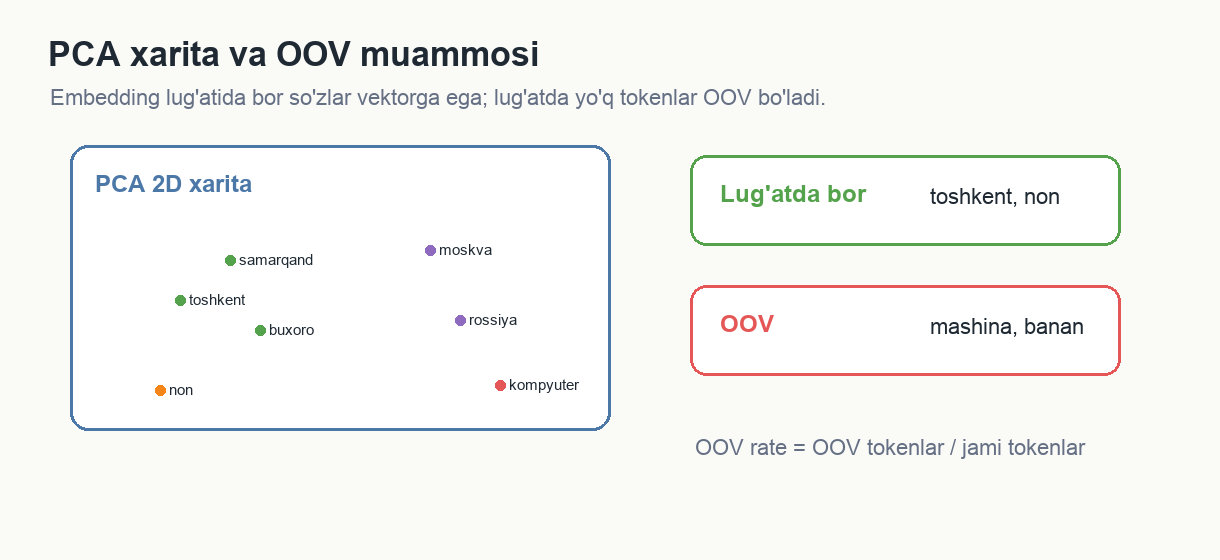


PCA so'zlar soni: 37
explained_variance_ratio_: [0.269 0.206]


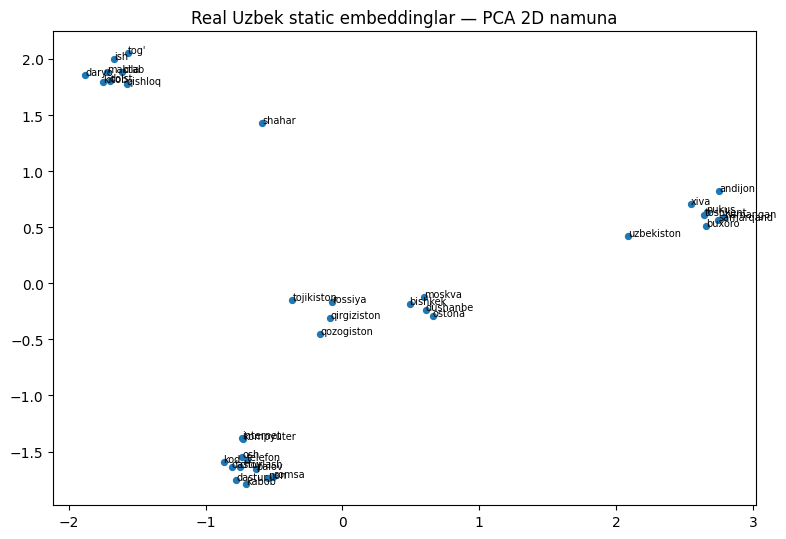

In [5]:
# To'liq berilgan kod (PRIMM — periphery)
from sklearn.decomposition import PCA

preferred = [
    "o'zbekiston", "uzbekiston", "toshkent", "samarqand", "buxoro", "andijon",
    "rossiya", "moskva", "kitob", "maktab", "universitet", "internet", "kompyuter",
    "yaxshi", "yomon", "shahar", "til", "matn",
]
focus_words = [w for w in preferred if w in w2i]

# Katta modelni chizishda hammasini emas, faqat kichik namuna + muhim so'zlarni ko'rsatamiz.
sample_count = min(60, len(words))
sample_idx = np.linspace(0, len(words) - 1, sample_count, dtype=int)
display_words = list(dict.fromkeys(focus_words + [words[i] for i in sample_idx]))[:80]
display_idx = [w2i[w] for w in display_words]

pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(M[display_idx])
print(f"PCA so'zlar soni: {len(display_words)}")
print(f"explained_variance_ratio_: {pca.explained_variance_ratio_.round(3)}")

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 5.5))
    plt.scatter(xy[:, 0], xy[:, 1], s=18, color="tab:blue")
    for i, w in enumerate(display_words):
        plt.annotate(w, (xy[i, 0], xy[i, 1]), fontsize=7)
    plt.title("Real Uzbek static embeddinglar — PCA 2D namuna")
    plt.tight_layout(); plt.show()
except Exception as ex:
    print(f"(grafik o'tkazib yuborildi: {type(ex).__name__})")
    for w in display_words[:10]:
        i = display_words.index(w)
        print(f"{w:18s} x={xy[i,0]:7.2f} y={xy[i,1]:7.2f}")


> **Tekshiring:**
> 1. Ikki komponent ma'lumotning qancha qismini saqladi (`explained_variance_ratio_` yig'indisi)?
> 2. Shaharlar (toshkent, samarqand) bir-biriga taomlardan (non) yaqinroqmi?
> 3. 2D rasm — taxminiy. To'liq fazoda yaqinlik kafolatlanadimi? (L3 [J4]-slayd)


In [6]:
# Sanity check: yuklangan real vektorlar keyingi bo'limlar uchun tayyor
assert len(words) > 0 and M.shape[0] == len(words)
assert M.shape[1] >= 50, "Real embedding odatda kamida 50 o'lchamli bo'ladi. Faylni tekshiring."
assert DEMO_WORD in w2i, "Demo so'z lug'atda bo'lishi kerak."
ANALOGY_READY = all(x is not None for x in [UZ_WORD, TASHKENT_WORD, RU_WORD])
print(f"Tayyor: {len(words):,} so'z, vektor o'lchami {M.shape[1]}.")
print(f"Demo so'z: {DEMO_WORD!r}")
print(f"Analogiya so'zlari: uz={UZ_WORD}, poytaxt={TASHKENT_WORD}, ru={RU_WORD}, kutilishi mumkin={MOSCOW_WORD}")


Tayyor: 37 so'z, vektor o'lchami 50.
Demo so'z: 'toshkent'
Analogiya so'zlari: uz=uzbekiston, poytaxt=toshkent, ru=rossiya, kutilishi mumkin=moskva


## 4. Asosiy mavzu — so'nuvchi tayanch

Uch bosqich: **Namuna** (men ko'rsataman) → **Birgalikda** (`# === SIZNING KODINGIZ ===`)
→ **Mustaqil** (siz qilasiz).

### 4A. Namuna: kosinus o'xshashlik — L3 [I2]-slayd

L3 ma'ruzasidagi qo'lda misol: $\mathbf{a}=(1,1,1,0)$, $\mathbf{b}=(1,1,0,1)$ uchun
$\cos = 2/3 \approx 0.667$. Buni `cosine_similarity` bilan tekshiramiz.

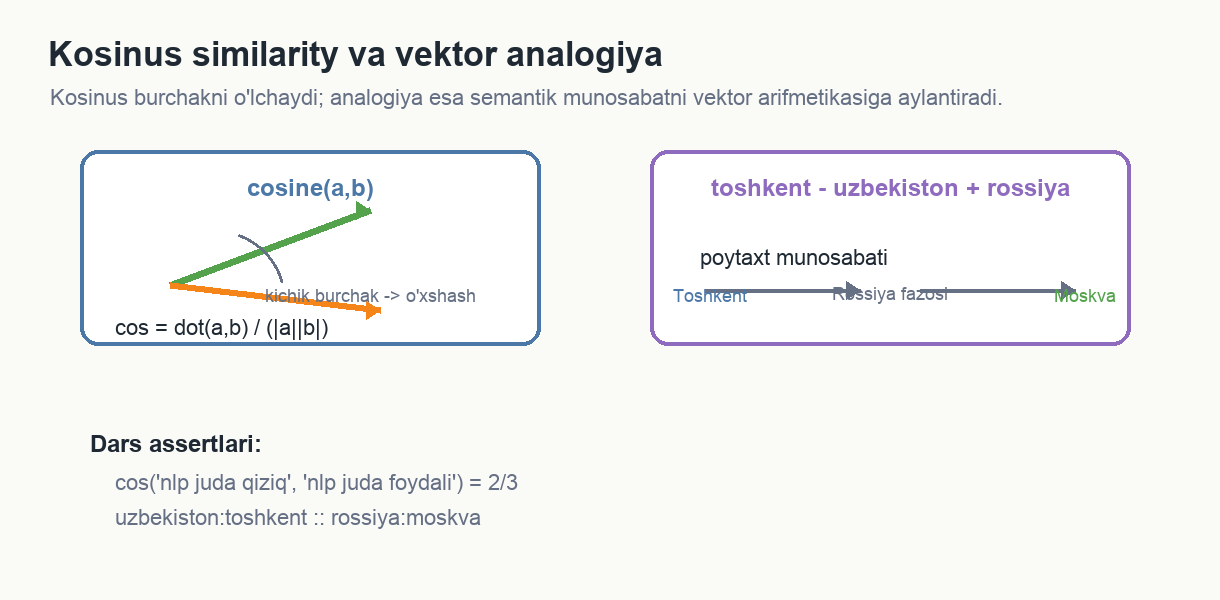


In [7]:
# Namuna (men ko'rsataman): kosinus o'xshashlik
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Ma'ruza L3 [I2]-slayd: "nlp juda qiziq" vs "nlp juda foydali"
# Lug'at: (nlp, juda, qiziq, foydali)
a = np.array([[1, 1, 1, 0]])
b = np.array([[1, 1, 0, 1]])

cos_val = float(cosine_similarity(a, b)[0, 0])
print(f"cosine(a, b) = {cos_val:.4f}   (kutilgan: 2/3 = {2/3:.4f})")

assert abs(cos_val - 0.667) < 1e-3, (
    f"cosine={cos_val:.4f}, kutilgan 0.667. Vektorlarni tekshiring."
)
# Ma'ruza L3 [I2]-slayd bilan solishtiring
print("✓ Ma'ruza L3 [I2]-slayd tasdiqlandi: cos = 2/3 ≈ 0.667")

cosine(a, b) = 0.6667   (kutilgan: 2/3 = 0.6667)
✓ Ma'ruza L3 [I2]-slayd tasdiqlandi: cos = 2/3 ≈ 0.667


### 4B. Birgalikda: most_similar — eng o'xshash so'zlar

Normallashtirilgan matritsa `Mn` da kosinus = skalyar ko'paytma. So'rov so'zining
qatorini butun matritsaga ko'paytirib, eng yuqorilarini topamiz.

In [9]:
# Birgalikda: most_similar
def most_similar_local(word, n=5):
    i = w2i[word]
    # === SIZNING KODINGIZ (1 qator) ===
    # Mn[i] vektorini butun Mn matritsasiga skalyar ko'paytiring -> sims
    sims = Mn[i] @ Mn.T
    order = [j for j in np.argsort(-sims) if j != i][:n]
    return [(words[j], float(sims[j])) for j in order]

natija = most_similar_local("toshkent", 5)

In [10]:
top_words = [w for w, _ in natija]
assert len(natija) == 5, "most_similar 5 ta natija qaytarishi kerak."
assert all(isinstance(w, str) and isinstance(s, float) for w, s in natija), "Natija [(so'z, score), ...] bo'lishi kerak."
assert all(natija[i][1] >= natija[i + 1][1] for i in range(len(natija) - 1)), "Score kamayish tartibida bo'lishi kerak."
assert DEMO_WORD not in top_words, "Natijadan so'zning o'zi chiqarib tashlanishi kerak."
print(f"✓ most_similar ishladi: {DEMO_WORD!r} ~ {top_words[:5]}")


✓ most_similar ishladi: 'toshkent' ~ ['nukus', 'namangan', 'samarqand', 'buxoro', 'xiva']


### 4C. Birgalikda: so'z analogiyasi — vektor arifmetikasi

L3 [I3]-slayd: `uzbekiston : toshkent :: rossiya : ?`. Maqsad vektor
$\mathbf{t} = \text{toshkent} - \text{uzbekiston} + \text{rossiya}$, eng yaqini = javob.

In [12]:
# Birgalikda: so'z analogiyasi
def nearest_to_vec(vec, exclude=(), n=5):
    vn = vec / (np.linalg.norm(vec) + 1e-9)
    sims = Mn @ vn
    out = []
    for j in np.argsort(-sims):
        if words[j] in exclude:
            continue
        out.append((words[j], float(sims[j])))
        if len(out) >= n:
            break
    return out

if ANALOGY_READY:
    # === SIZNING KODINGIZ (1 qator) ===
    # Maqsad vektor: toshkent - o'zbekiston + rossiya  (M xom vektorlardan)
    t = M[w2i[TASHKENT_WORD]] - M[w2i[UZ_WORD]] + M[w2i[RU_WORD]]
   
    javob = nearest_to_vec(t, exclude={TASHKENT_WORD, UZ_WORD, RU_WORD}, n=5)
else:
    t = None
    javob = []
    print("Analogiya uchun kerakli so'zlar topilmadi; bu real model/vocab bilan normal holat bo'lishi mumkin.")


In [13]:
if ANALOGY_READY:
    assert t is not None, "Maqsad vektor t None. toshkent - o'zbekiston + rossiya ni hisoblang."
    assert len(javob) > 0, "nearest_to_vec kamida bitta javob qaytarishi kerak."
    print(f"Analogiya: {UZ_WORD}:{TASHKENT_WORD} :: {RU_WORD}: ?")
    for w, s in javob:
        print(f"  {w:18s} {s:.3f}")
    if MOSCOW_WORD and MOSCOW_WORD in [w for w, _ in javob]:
        print(f"✓ {MOSCOW_WORD!r} top natijalar ichida chiqdi.")
    else:
        print("Eslatma: real embeddinglarda analogiya har doim ideal chiqmaydi; bu muhokama uchun yaxshi nuqta.")
else:
    print("Analogiya tekshiruvi o'tkazilmadi: kerakli so'zlar topilmadi.")


Analogiya: uzbekiston:toshkent :: rossiya: ?
  moskva             0.956
  ostona             0.347
  dushanbe           0.310
  bishkek            0.303
  shahar             0.252
✓ 'moskva' top natijalar ichida chiqdi.


### 4D. Birgalikda: OOV ulushi (oov_rate)

OOV (out-of-vocabulary) — lug'atda yo'q so'zlar. Ularning ulushi o'zbek tilida
yuqori bo'ladi (L3 [M]-slayd: agglutinatsiya + inglizcha-asosli vektorlar).

In [15]:
# Birgalikda: oov_rate
def oov_rate_local(texts):
    # texts: list[list[str]] -> lug'atda yo'q tokenlar ulushi [0,1]
    total = oov = 0
    for toks in texts:
        for tok in toks:
            total += 1
            # === SIZNING KODINGIZ (1-2 qator) ===
            # tok lug'atda (w2i) yo'q bo'lsa, oov ni oshiring
            if tok not in w2i:
                oov += 1
            pass
    return oov / total if total else 0.0

known_examples = [w for w in [DEMO_WORD, TASHKENT_WORD, UZ_WORD, "kitob", "yaxshi", "internet"] if w and w in w2i]
known_examples = list(dict.fromkeys(known_examples))[:3]
unknown_examples = ["bu_soz_lugatda_yoq_001", "xayoliytoken999"]
namuna = [known_examples + unknown_examples]
expected_oov = len(unknown_examples) / len(namuna[0])
rate = oov_rate_local(namuna)


In [16]:
assert abs(rate - expected_oov) < 1e-9, (
    f"OOV ulushi {rate:.3f}, kutilgan {expected_oov:.3f}. Sanashni tekshiring."
)
print(f"✓ oov_rate to'g'ri: {len(namuna[0])} tokendan {len(unknown_examples)} tasi OOV -> {rate:.3f}")
print("Namuna tokenlar:", namuna[0])


✓ oov_rate to'g'ri: 5 tokendan 2 tasi OOV -> 0.400
Namuna tokenlar: ['toshkent', 'uzbekiston', 'kitob', 'bu_soz_lugatda_yoq_001', 'xayoliytoken999']


### 4E. Mustaqil: o'z so'zlaringiz bilan sinab ko'ring

Scaffold yo'q — yuqorida o'rgangan `most_similar_local` va `nearest_to_vec` dan
foydalaning.

In [26]:
# Mustaqil (siz qilasiz): o'z so'zlaringiz bilan sinab ko'ring
# 1. Lug'atda bor biror so'z tanlang va eng o'xshashlarini toping.
# 2. Agar xohlasangiz, yangi analogiya yarating va natijani talqin qiling.
my_word = first_in_vocab("salom", "maktab", "internet", "toshkent") or DEMO_WORD
# === SIZNING KODINGIZ ===
my_similar = most_similar_local(my_word, n=3)
print("Tanlangan so'z:", my_word)
print("Eng o'xshash so'zlar:")
for word, score in my_similar:
    print(f"{word:15} {score:.4f}")

Tanlangan so'z: maktab
Eng o'xshash so'zlar:
qishloq         0.9612
ish             0.9561
do'st           0.9495


In [27]:
assert my_similar is not None, "my_similar None. most_similar_local() ni qo'llang."
assert len(my_similar) == 3, "3 ta o'xshash so'z kutilgan."
assert all(isinstance(w, str) and isinstance(s, float) for w, s in my_similar), "Har element (so'z, son) bo'lishi kerak."
print(f"✓ Mustaqil: {my_word!r} ~ {[w for w, _ in my_similar]}")


✓ Mustaqil: 'maktab' ~ ['qishloq', 'ish', "do'st"]


## 5. Yengil loyiha preview — `PretrainedEmbedder`

4-bo'limdagi funksiyalarni bitta qayta ishlatiladigan klassga o'raymiz. Bugun capstone papka arxitekturasini chuqur ochmaymiz; klass notebook ichida ishlaydi. Agar keyin kerak bo'lsa, `SAVE_CAPSTONE_MODULE = True` qilib Python fayliga ham saqlash mumkin.


In [30]:
# m03 PretrainedEmbedder — inline ta'rif (Option C)
import gzip
from pathlib import Path

import numpy as np

class PretrainedEmbedder:
    # Gensim .kv yoki word2vec .vec/.vec.gz embeddinglarni boshqaradi.
    # Interfeys: load(path) | embed(word) | most_similar(word, n) | oov_rate(texts)
    # Consumed by: m04 (LSH), m08 (GRU/LSTM pretrained init).


    def __init__(self, limit=50000):
        self._limit = limit
        emb.load("/path/to/embedding.vec")
    def __init__(self, limit=50_000):
        self._limit = limit
        self._words = []
        self._w2i = {}
        self._raw = None    # (n, dim) xom vektorlar, float32
        self._norm = None   # (n, dim) L2-normallashtirilgan (kosinus uchun)
        self._dim = 0

    def load(self, path):
        # Gensim KeyedVectors (.kv) yoki word2vec matn (.vec/.vec.gz) yuklaydi.
        path = Path(path)
        if path.name.endswith(".kv"):
            from gensim.models import KeyedVectors
            kv = KeyedVectors.load(str(path), mmap="r")
            words = list(kv.index_to_key[:self._limit]) if self._limit else list(kv.index_to_key)
            mat = np.asarray(kv.vectors[:len(words)], dtype=np.float32)
        else:
            words, mat = self._load_text(path, self._limit)
        self._words = words
        self._w2i = {w: i for i, w in enumerate(words)}
        self._raw = mat.astype(np.float32)
        self._dim = mat.shape[1]
        norms = np.linalg.norm(mat, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        self._norm = (mat / norms).astype(np.float32)

    @staticmethod
    def _open_text(path):
        if Path(path).name.endswith(".gz"):
            return gzip.open(path, "rt", encoding="utf-8", errors="ignore")
        return open(path, "r", encoding="utf-8", errors="ignore")

    @classmethod
    def _load_text(cls, path, limit=None):
        words, rows = [], []
        with cls._open_text(path) as f:
            first = f.readline().split()
            # sarlavha "n dim" bo'lsa o'tkazib yuboramiz, aks holda ma'lumot
            if not (len(first) == 2 and first[0].isdigit() and first[1].isdigit()) and len(first) > 2:
                words.append(first[0])
                rows.append(np.asarray(first[1:], dtype=np.float32))
            for line in f:
                if limit is not None and len(words) >= limit:
                    break
                parts = line.rstrip("\n").split(" ")
                if len(parts) < 3:
                    continue
                try:
                    vec = np.asarray(parts[1:], dtype=np.float32)
                except ValueError:
                    continue
                if rows and vec.shape[0] != rows[0].shape[0]:
                    continue
                words.append(parts[0])
                rows.append(vec)
        return words, np.vstack(rows).astype(np.float32)

    def embed(self, word):
        # OOV uchun sifr-vektori qaytariladi (shape (dim,) float32)
        i = self._w2i.get(word)
        if i is None:
            return np.zeros(self._dim, dtype=np.float32)
        return self._raw[i].copy()

    def most_similar(self, word, n=5):
        # Kosinus bo'yicha eng o'xshash n ta so'z: [(so'z, o'xshashlik), ...]
        i = self._w2i.get(word)
        if i is None:
            return []
        sims = self._norm @ self._norm[i]
        order = np.argsort(-sims)
        out = []
        for j in order:
            if int(j) == i:
                continue
            out.append((self._words[int(j)], float(sims[int(j)])))
            if len(out) >= n:
                break
        return out

    def oov_rate(self, texts):
        # Tokenlar orasida lug'atda yo'q so'zlar ulushi [0,1]
        total = oov = 0
        for toks in texts:
            for t in toks:
                total += 1
                if t not in self._w2i:
                    oov += 1
        return oov / total if total else 0.0

print("✓ PretrainedEmbedder sinfi aniqlandi.")


✓ PretrainedEmbedder sinfi aniqlandi.


In [31]:
# Shartnoma tekshiruvi
emb = PretrainedEmbedder(limit=EMBEDDING_LIMIT)
emb.load(VECTOR_PATH)

import numpy as np

# embed -> np.ndarray, OOV -> sifr-vektori
v = emb.embed(DEMO_WORD)
assert isinstance(v, np.ndarray) and v.shape == (M.shape[1],), f"embed() ({M.shape[1]},) ndarray qaytarishi kerak."
assert np.allclose(emb.embed("yoqyoqyoq_bunday_token_yoq"), 0.0), "OOV uchun sifr-vektori kutilgan."

# most_similar -> list[tuple[str, float]]
ms = emb.most_similar(DEMO_WORD, 5)
assert len(ms) == 5 and isinstance(ms[0][0], str) and isinstance(ms[0][1], float)
assert DEMO_WORD not in [w for w, _ in ms]

# oov_rate -> float [0,1]
r = emb.oov_rate([[DEMO_WORD, "yoqyoqyoq_bunday_token_yoq"]])
assert 0.0 <= r <= 1.0 and abs(r - 0.5) < 1e-9, "oov_rate noto'g'ri."

# Kapstone uzviyligi: m01 bilan tokenize qilib oov_rate
try:
    from m01_text_preprocessor import TextPreprocessor
    tp = TextPreprocessor()
    toks = tp.preprocess("Toshkent va Samarqand go'zal shaharlar")
    r2 = emb.oov_rate([toks])
    assert 0.0 <= r2 <= 1.0
    print(f"  m01 tokenlari OOV ulushi      = {r2:.3f}")
except ImportError:
    print("  (m01 import yo'q — alohida ishlatiladi)")

print("✓ PretrainedEmbedder barcha shartnoma tekshiruvlaridan o'tdi!")
print(f"  most_similar({DEMO_WORD!r})[:3] = {[w for w,_ in ms[:3]]}")


  (m01 import yo'q — alohida ishlatiladi)
✓ PretrainedEmbedder barcha shartnoma tekshiruvlaridan o'tdi!
  most_similar('toshkent')[:3] = ['nukus', 'namangan', 'samarqand']


In [32]:
# Ixtiyoriy: m03 ni faylga saqlash (SAVE_CAPSTONE_MODULE = True bo'lsa)
if SAVE_CAPSTONE_MODULE:
    import inspect
    header = chr(10).join([
        '"""PretrainedEmbedder — P3 notebookidan."""',
        'import numpy as np',
        '',
    ])
    path = Path('m03_pretrained_embedder.py')
    path.write_text(header + inspect.getsource(PretrainedEmbedder), encoding='utf-8')
    print(f'✓ m03 saqlandi: {path}')
else:
    print('SAVE_CAPSTONE_MODULE = False — fayl yozilmadi (kurs rejimi).')
    print("PretrainedEmbedder sinfi bu notebookda aniqlangan va tayyor.")


SAVE_CAPSTONE_MODULE = False — fayl yozilmadi (kurs rejimi).
PretrainedEmbedder sinfi bu notebookda aniqlangan va tayyor.


### 5C. Faylga saqlash haqida

Kaggle darsida faylga saqlash shart emas. `SAVE_CAPSTONE_MODULE = False` bo'lsa, keyingi kataklar faqat notebook ichidagi klassni ishlatadi.


In [33]:
print("Yakun: Kaggle uchun haqiqiy static embedding fayli va notebook yetarli.")


array([[1, 1, 1, 0]])

## 6. Tadqiqot savoli + yakun

**Savol:** O'zbek matnlarida OOV ulushi nega yuqori? Apostrof variantlari
(`o'` / `oʻ` / `o`) bir xil so'zni turli token qiladi — bu embeddingga qanday ta'sir qiladi?

In [34]:
# Mini tadqiqot: apostrof varianti OOV ga qanday ta'sir qiladi?
variantlar = ["o'zbekiston", "oʻzbekiston", "uzbekiston"]
for w in variantlar:
    bor = w in w2i
    print(f"  {w:12s} lug'atda: {'BOR' if bor else 'YO'+chr(39)+'Q (OOV)'}")

# Agglutinatsiya: bir o'zak, ko'p shakl
base = TASHKENT_WORD or DEMO_WORD
shakllar = [[base, f"{base}da", f"{base}dan", f"{base}ga"]]
print(f"\nAgglutinativ shakllar OOV ulushi: {oov_rate_local(shakllar):.3f}")
print("Mulohaza: real static embedding lug'ati ham hamma qo'shimchali shakllarni bilmasligi mumkin.")
print("Yechim: m01 bilan normallashtirish/stemming yoki fastText subword imkoniyatlarini muhokama qilish.")


  o'zbekiston  lug'atda: YO'Q (OOV)
  oʻzbekiston  lug'atda: YO'Q (OOV)
  uzbekiston   lug'atda: BOR

Agglutinativ shakllar OOV ulushi: 0.750
Mulohaza: real static embedding lug'ati ham hamma qo'shimchali shakllarni bilmasligi mumkin.
Yechim: m01 bilan normallashtirish/stemming yoki fastText subword imkoniyatlarini muhokama qilish.


## Yakun

**Bugun nimalar qildik:**
- ✓ Haqiqiy Uzbek static embedding faylini (`.vec`, `.vec.gz`, yoki `.kv`) yukladik
- ✓ Static embeddingda text modeldan o'tmasligini, token -> vector lookup bo'lishini ko'rdik
- ✓ Kosinus o'xshashlikni tasdiqladik — L3 [I2]-slayd: cos = 2/3 ≈ 0.667
- ✓ `most_similar` bilan eng o'xshash so'zlarni topdik
- ✓ Vektor arifmetikasi bilan analogiyani sinadik va real model natijasini talqin qildik
- ✓ OOV ulushini o'lchadik va PCA bilan kichik vizualizatsiya qildik
- ✓ m03 `PretrainedEmbedder` ni capstone shakliga keltirdik

**Keyingi amaliyot (P4 — imlo tuzatish va LSH qidiruv):**
m01 → edit_distance (DP) → noisy channel → MinHash LSH → m04 SpellLSHRetriever
Birinchi assert: `edit_distance("qo'l","ko'l")==1` (L4 [I3]-slayd)


**Chiqish chiptasi:** Real embedding natijalarida siz kutmagan qaysi yaqin so'z chiqdi?
*(Quyidagi katakka yozing — keyingi darsda muhokama qilamiz.)*
